# 23b visualize oscillation scale check

`23-check_osc_scale.py` の結果を確認する notebook。

**目的**: ALP 振動の comoving 波長 $\lambda_{\rm osc}(m_a)$ を bubble scale $R_{\rm eff}$ および
visibility function の幅 $\Delta\chi_{\rm vis}$ と比較し、thin-shell 近似の妥当性と
空間的共鳴増幅の可能性を検討する。

**結果の読み方**:
- $\lambda_{\rm osc} = R_{\rm eff}$ となる質量 $m_{\rm res}$: 空間的共鳴が起きうる質量
- $m_{\rm best}$ における $\lambda_{\rm osc} \ll R_{\rm eff}$: preferred mass では空間共鳴なし
- $N_{\rm osc} = \Delta\chi_{\rm patchy}/\lambda_{\rm osc} \gg 1$: 位相平均化により thin-shell が $A_{\rm eff}$ を過大/過少評価しうる（Script 24 で定量化）

In [6]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path('/home/yminami/workdir/CosmicBirefringence/PatchyReionization')
OUT = ROOT / 'results' / '23-osc-scale'
CSV = OUT / 'osc_scale_scan.csv'

df = pd.read_csv(CSV)
display(Markdown(f'**Output dir:** `{OUT}`'))
display(df.head(10))

**Output dir:** `/home/yminami/workdir/CosmicBirefringence/PatchyReionization/results/23-osc-scale`

,mass_eV,lambda_osc_Mpc,N_osc_full,N_osc_patchy
0,1.000000e-33,349570.717361,0.014345,0.002643
1,1.109752e-33,314998.811439,0.015920,0.002933
2,1.231551e-33,283846.003913,0.017667,0.003255
3,1.366716e-33,255774.152192,0.019606,0.003612
4,1.516717e-33,230478.555371,0.021758,0.004008
5,1.683180e-33,207684.646906,0.024146,0.004448
6,1.867914e-33,187145.014386,0.026796,0.004936
7,2.072922e-33,168636.714034,0.029736,0.005478
8,2.300430e-33,151958.850807,0.033000,0.006079
9,2.552908e-33,136930.397812,0.036622,0.006747


In [7]:
# preferred mass から key quantities を確認
m_best = 5.878016e-27
row = df.iloc[(df['mass_eV'] - m_best).abs().argsort()[:1]]
display(Markdown('## Key values at preferred mass $m_{\\rm best}$'))
display(row[['mass_eV', 'lambda_osc_Mpc', 'N_osc_full', 'N_osc_patchy']].rename(columns={
    'mass_eV': 'm_a [eV]',
    'lambda_osc_Mpc': 'lambda_osc [Mpc]',
    'N_osc_full': 'N_osc (full vis)',
    'N_osc_patchy': 'N_osc (patchy dz=3)',
}))
print(f"lambda_osc     = {row['lambda_osc_Mpc'].values[0]*1e3:.1f} kpc")
print(f"N_osc (full)   = {row['N_osc_full'].values[0]:.0f}")
print(f"N_osc (patchy) = {row['N_osc_patchy'].values[0]:.0f}")

## Key values at preferred mass $m_{\rm best}$

,m_a [eV],lambda_osc [Mpc],N_osc (full vis),N_osc (patchy dz=3)
150,6.080224e-27,0.057493,87221.858085,16068.205983


lambda_osc     = 57.5 kpc
N_osc (full)   = 87222
N_osc (patchy) = 16068


## osc_scale_vs_m.png

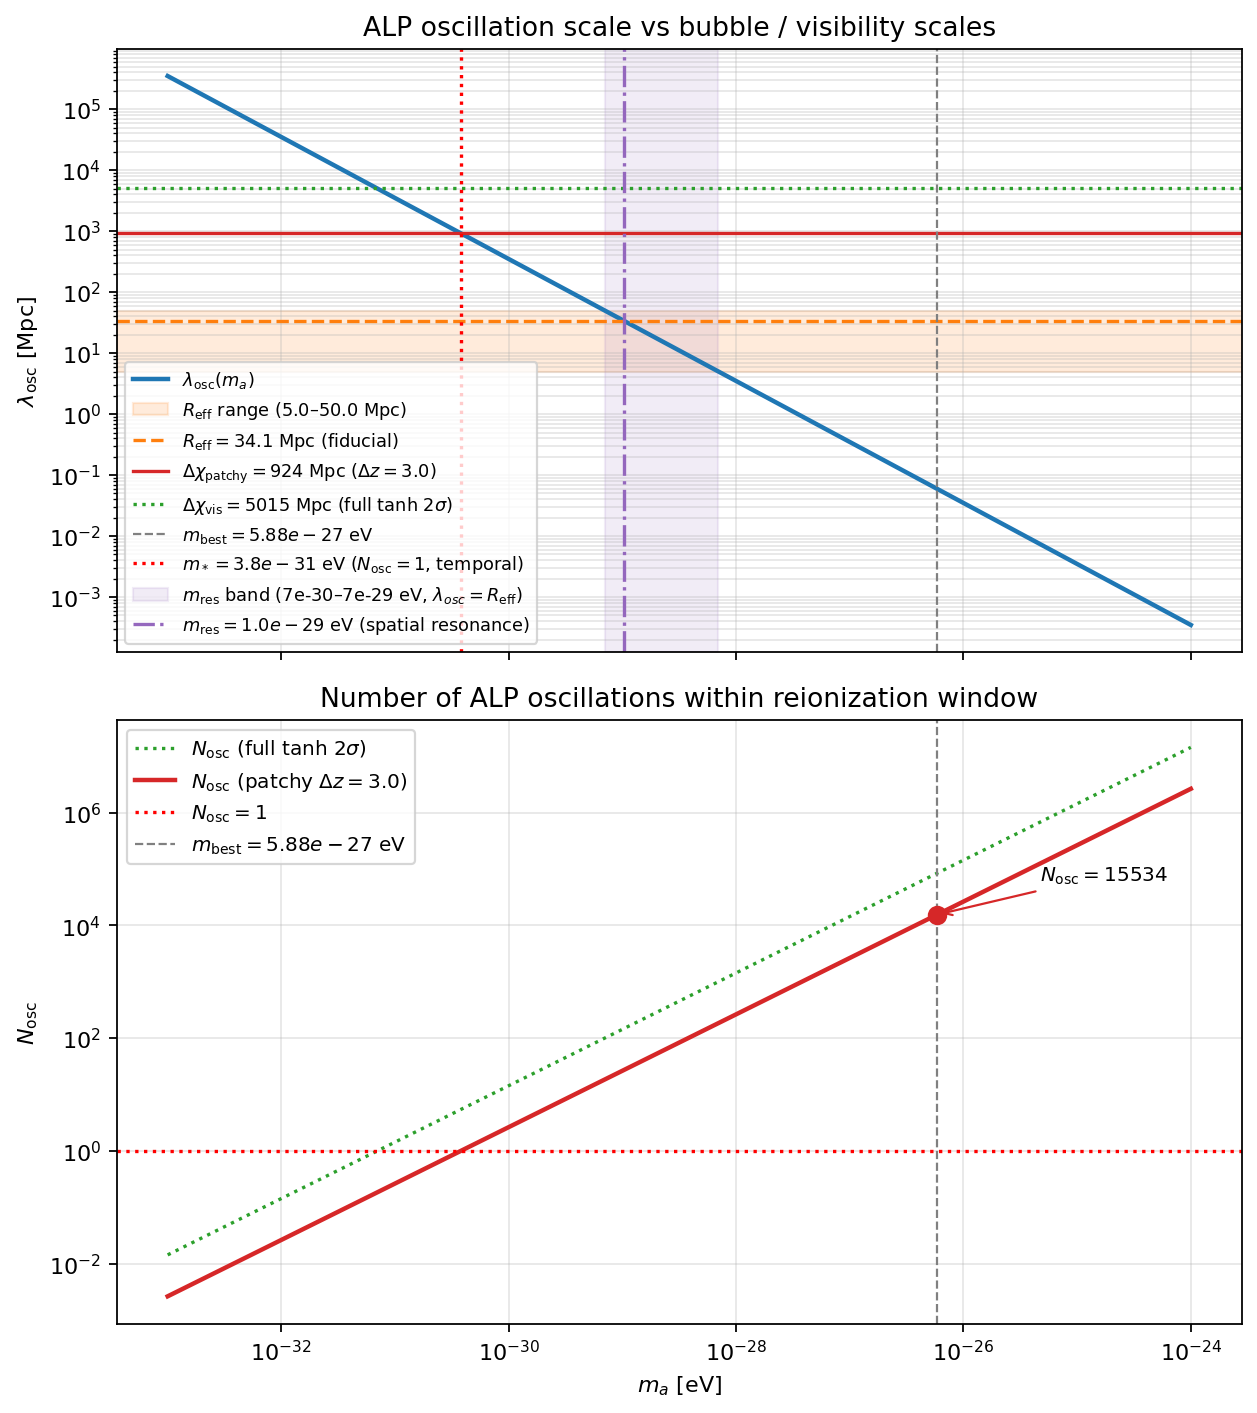

In [8]:
display(Markdown('## osc_scale_vs_m.png'))
display(Image(filename=str(OUT / 'osc_scale_vs_m.png')))

In [9]:
display(Markdown('## Summary'))
display(Markdown((OUT / 'summary.md').read_text()))

## Summary

# 23-check_osc_scale summary

Step 1 of Caveat 2 verification: compare lambda_osc(m_a) to R_eff and Delta_chi_vis.

## Visibility function (tanh model)
- `z_rei = 7.7`, `delta_y = 19.0`
- `chi_rei = 9036.7 Mpc`
- `sigma_chi = 2507.3 Mpc`  (1-sigma comoving width of g(chi))
- `fwhm_chi = 5904.3 Mpc`
- `tau_total = 0.0508`
- `delta_chi_vis (2 sigma, full tanh) = 5014.7 Mpc`

## Patchy reionization epoch width
- `delta_z_patchy = 3.0` (width of the epoch where delta_x_e fluctuates)
- `dchi/dz at z_rei = 307.9 Mpc/dz`
- `delta_chi_patchy = 923.8 Mpc`
  (This is the physically relevant window for the thin-shell approximation.)

## Bubble scale reference
- `R_eff (fiducial, from run 22) = 34.1 Mpc`
- `R_eff range = 5.0--50.0 Mpc`

## At the preferred mass
- `m_best = 5.878016e-27 eV`
- `lambda_osc = 0.0595 Mpc = 59.5 kpc`
- `N_osc (full vis)      = 84321.1`
- `N_osc (patchy epoch)  = 15533.8`

## Crossover mass (N_osc = 1, patchy epoch)
- `m_crossover = 3.784e-31 eV`
  For m_a > m_crossover, N_osc > 1 and the thin-shell approximation
  evaluates dotphi at a single phase while the full integral averages
  over many oscillation periods — potentially giving a much smaller A_eff.

## Spatial resonance mass (lambda_osc = R_eff)
- `m_res (fiducial, R_eff=34.139 Mpc) = 1.024e-29 eV`
- `m_res range (5.0--50.0 Mpc) = 6.99e-30--6.99e-29 eV`
  At m_res, lambda_osc = R_eff and spatial resonance between ALP oscillations
  and bubble clustering is in principle possible.
  m_res is ~3 orders of magnitude below m_best.

## Interpretation
- At `m_best`, `lambda_osc << R_eff`: no spatial resonance at the preferred mass.
- Spatial resonance would occur at `m_res ~ 1e-29 eV`, which is far from m_best.
  Whether this mass range is physically interesting requires separate investigation.
- `N_osc >> 1` at the preferred mass: many oscillation periods fit in the
  visibility window. The dominant concern is temporal phase averaging, not spatial.
  The full visibility-weighted A_eff is quantified in script 24.


sigma_chi        = 2507.3 Mpc
delta_chi_vis    = 5014.6 Mpc
delta_chi_patchy = 923.8 Mpc


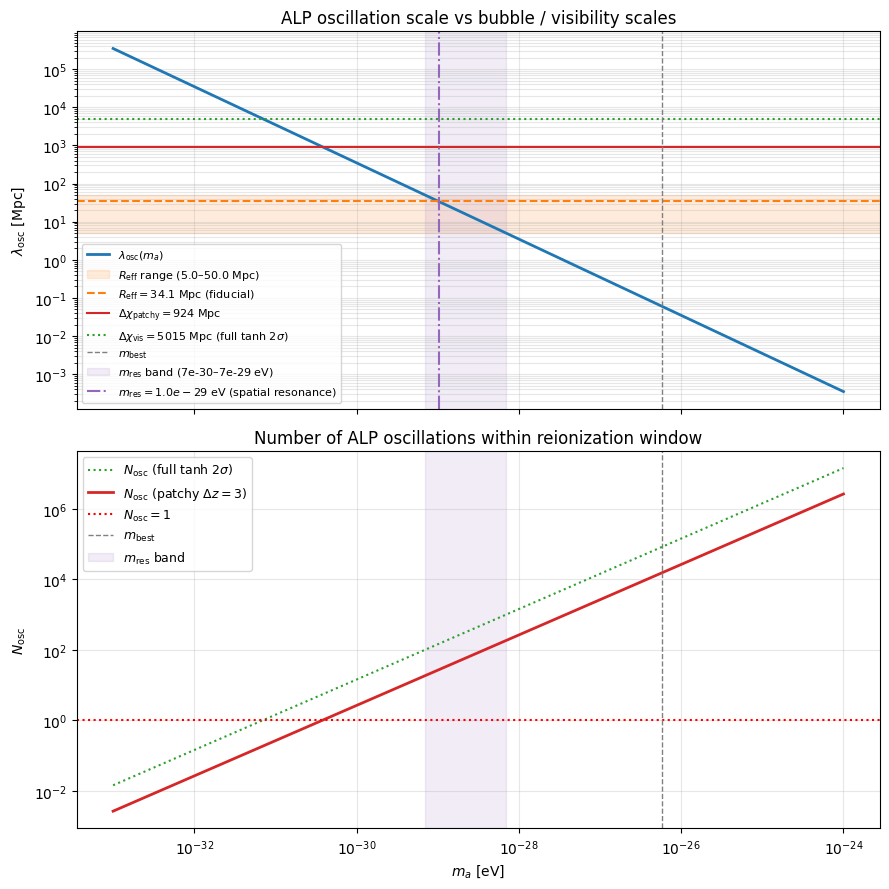

In [10]:
# 簡易図: 同じデータを notebook でも直接プロット
import matplotlib.pyplot as plt
import numpy as np

R_eff        = 34.139  # Mpc, fiducial from run 22
R_eff_min    = 5.0
R_eff_max    = 50.0
# spatial resonance masses: lambda_osc = R_eff
# m_res ~ 1e-29 eV (fiducial), see summary.md
m_res_fid    = 1.024e-29
m_res_lo     = 6.99e-30
m_res_hi     = 6.99e-29

# summary.md から sigma_chi と delta_chi_patchy を抽出
summary_text = (OUT / 'summary.md').read_text()
sigma_chi = delta_chi_patchy = None
for line in summary_text.splitlines():
    if 'sigma_chi' in line and '1-sigma' in line and sigma_chi is None:
        sigma_chi = float(line.split('=')[1].split('Mpc')[0].strip().replace('`', ''))
    if 'delta_chi_patchy' in line and 'Mpc' in line and delta_chi_patchy is None:
        try:
            delta_chi_patchy = float(line.split('=')[1].split('Mpc')[0].strip().replace('`', ''))
        except (IndexError, ValueError):
            pass
delta_chi_vis = 2 * sigma_chi
print(f"sigma_chi        = {sigma_chi:.1f} Mpc")
print(f"delta_chi_vis    = {delta_chi_vis:.1f} Mpc")
print(f"delta_chi_patchy = {delta_chi_patchy:.1f} Mpc")

fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

# Panel 1: lambda_osc vs m_a
ax = axes[0]
ax.loglog(df['mass_eV'], df['lambda_osc_Mpc'], 'C0', lw=2,
          label=r'$\lambda_{\rm osc}(m_a)$')
ax.axhspan(R_eff_min, R_eff_max, alpha=0.15, color='C1',
           label=f'$R_{{\\rm eff}}$ range ({R_eff_min}–{R_eff_max} Mpc)')
ax.axhline(R_eff, color='C1', ls='--', lw=1.5,
           label=f'$R_{{\\rm eff}} = {R_eff:.1f}$ Mpc (fiducial)')
ax.axhline(delta_chi_patchy, color='C3', ls='-', lw=1.5,
           label=rf'$\Delta\chi_{{\rm patchy}} = {delta_chi_patchy:.0f}$ Mpc')
ax.axhline(delta_chi_vis, color='C2', ls=':', lw=1.5,
           label=rf'$\Delta\chi_{{\rm vis}} = {delta_chi_vis:.0f}$ Mpc (full tanh $2\sigma$)')
ax.axvline(m_best, color='gray', ls='--', lw=1, label=r'$m_{\rm best}$')
ax.axvspan(m_res_lo, m_res_hi, alpha=0.12, color='C4',
           label=rf'$m_{{\rm res}}$ band ({m_res_lo:.0e}–{m_res_hi:.0e} eV)')
ax.axvline(m_res_fid, color='C4', ls='-.', lw=1.5,
           label=rf'$m_{{\rm res}} = {m_res_fid:.1e}$ eV (spatial resonance)')
ax.set_ylabel(r'$\lambda_{\rm osc}$ [Mpc]')
ax.legend(fontsize=8, loc='lower left')
ax.grid(True, which='both', alpha=0.3)
ax.set_title(r'ALP oscillation scale vs bubble / visibility scales')

# Panel 2: N_osc vs m_a
ax = axes[1]
ax.loglog(df['mass_eV'], df['N_osc_full'], 'C2', lw=1.5, ls=':',
          label=r'$N_{\rm osc}$ (full tanh $2\sigma$)')
ax.loglog(df['mass_eV'], df['N_osc_patchy'], 'C3', lw=2,
          label=r'$N_{\rm osc}$ (patchy $\Delta z=3$)')
ax.axhline(1.0, color='red', ls=':', lw=1.5, label=r'$N_{\rm osc} = 1$')
ax.axvline(m_best, color='gray', ls='--', lw=1, label=r'$m_{\rm best}$')
ax.axvspan(m_res_lo, m_res_hi, alpha=0.12, color='C4',
           label=r'$m_{\rm res}$ band')
ax.set_xlabel(r'$m_a$ [eV]')
ax.set_ylabel(r'$N_{\rm osc}$')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
ax.set_title(r'Number of ALP oscillations within reionization window')

plt.tight_layout()
plt.show()